# Lab 2 — Index Business Graph Images into ChromaDB

This notebook embeds each business graph images using **Cohere embed-v4.0** and stores the vectors in a local **ChromaDB** collection.

**Before running:** make sure you have copied `.env.example` to `.env` at the project root and update.

In [1]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)  # loads .env from the project root

import io
import os
import base64
import time
from tqdm.notebook import tqdm
import cohere
import chromadb
from PIL import Image

# --- Configuration ---
chromadb_path = os.environ.get('CHROMA_DB_PATH', './chroma_db')
collection_name = 'Business_Graphs'
MODEL = os.environ['EMBED_MODEL']
images_folder = './dataset/'
skip = -1  # last successfully indexed position; set to -1 to start fresh

# Azure APIM counts the base64 string as text tokens (~1 token per 4 chars).
# 8,000 token limit → 32,000 base64 chars → ~24KB JPEG max.
# We target 20KB to leave headroom (~26K chars / ~6,500 tokens).
MAX_JPEG_BYTES = 20_000

# --- Clients ---
co = cohere.ClientV2(
    base_url=os.environ['EMBED_BASE_URL'],
    api_key=os.environ['EMBED_API_KEY'], 
    timeout=300)
chroma_client = chromadb.PersistentClient(path=chromadb_path)

def local_image_to_base64(filename):
    try:
        img = Image.open(filename).convert("RGB")

        # Step 1: reduce JPEG quality in steps until under the byte budget
        image_data = None
        for quality in range(85, 9, -10):
            buf = io.BytesIO()
            img.save(buf, format="JPEG", quality=quality)
            image_data = buf.getvalue()
            if len(image_data) <= MAX_JPEG_BYTES:
                break

        # Step 2: if quality alone wasn't enough, shrink dimensions by 25% per iteration
        while len(image_data) > MAX_JPEG_BYTES and min(img.size) > 32:
            w, h = img.size
            img = img.resize((int(w * 0.75), int(h * 0.75)), Image.LANCZOS)
            buf = io.BytesIO()
            img.save(buf, format="JPEG", quality=15)
            image_data = buf.getvalue()

        encoded_string = base64.b64encode(image_data).decode('utf-8')
        print(f"    → size={img.size}  jpeg={len(image_data):,}B  b64={len(encoded_string):,} chars  (~{len(encoded_string)//4:,} tokens)")
        return encoded_string, len(image_data)
    except FileNotFoundError:
        print(f"===> ERROR: File '{filename}' not found.")
        return None, None
    except Exception as e:
        print(f"===> ERROR: {str(e)}")
        return None, None

# --- Collection setup ---
existing_collections = chroma_client.list_collections()
collection_exists = any(col.name == collection_name for col in existing_collections)
if skip == -1:
    if collection_exists:
        chroma_client.delete_collection(name=collection_name)
        print(f"Collection '{collection_name}' deleted. Creating new collection.")
    else:
        print(f"Collection '{collection_name}' does not exist. Creating new collection.")
    collection = chroma_client.create_collection(name=collection_name)
else:
    print(f"Resuming collection '{collection_name}' from index {skip}.")
    collection = chroma_client.get_collection(name=collection_name)

# --- Index images ---
jpg_files = [f for f in os.listdir(images_folder) if f.lower().endswith(('.jpg', '.jpeg'))]
jpg_files_sorted = sorted(jpg_files, key=lambda x: x.lower())

index = 0
for filename in tqdm(jpg_files_sorted, desc="Indexing images"):
    if index <= skip:
        index += 1
        continue

    file_path = os.path.join(images_folder, filename)
    print(f'===> index={index} filename={filename}')
    base64_encoded_image, image_size = local_image_to_base64(file_path)

    if base64_encoded_image is None:
        index += 1
        continue

    metadata = {
        'type': 'Graph',
        'filename': filename,
        'filepath': file_path,
        'image_size': image_size,
        'index': index + 1,
    }

    embeddings = co.embed(
        images=[f"data:image/jpg;base64,{base64_encoded_image}"],
        model=MODEL,
        input_type='search_document',
        embedding_types=['float']
    ).embeddings.float_[0]

    collection.add(
        documents=[filename],
        embeddings=[embeddings],
        ids=[str(index + 1)],
        metadatas=[metadata]
    )
    time.sleep(2)
    index += 1

print(f"\nDone! Indexed {index} images into ChromaDB collection '{collection_name}'.")
print(f"ChromaDB stored at: {os.path.abspath(chromadb_path)}")


Collection 'Business_Graphs' deleted. Creating new collection.


Indexing images:   0%|          | 0/4 [00:00<?, ?it/s]

===> index=0 filename=graph_0.jpg
    → size=(398, 432)  jpeg=12,246B  b64=16,328 chars  (~4,082 tokens)
===> index=1 filename=graph_1.jpg
    → size=(480, 576)  jpeg=17,706B  b64=23,608 chars  (~5,902 tokens)
===> index=2 filename=graph_2.jpg
    → size=(441, 576)  jpeg=19,856B  b64=26,476 chars  (~6,619 tokens)
===> index=3 filename=graph_3.jpg
    → size=(576, 576)  jpeg=17,174B  b64=22,900 chars  (~5,725 tokens)

Done! Indexed 4 images into ChromaDB collection 'Business_Graphs'.
ChromaDB stored at: /Users/andytran/Desktop/Github/cohere-azure-workshops/lab-3-embed-business-graphs/chroma_db


# Search for best chart in chroma_db database

Searching for: 'bar chart showing quarterly revenue growth'



Number of requested results 5 is greater than number of elements in index 4, updating n_results = 4


[1] graph_3.jpg  (similarity: -0.4579)


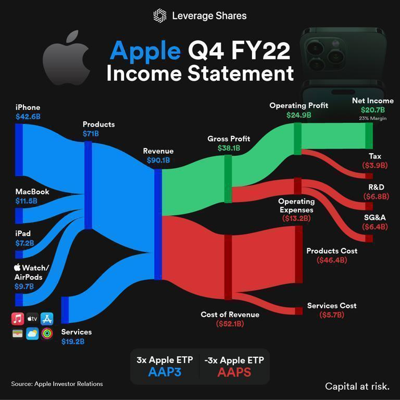


[2] graph_0.jpg  (similarity: -0.8721)


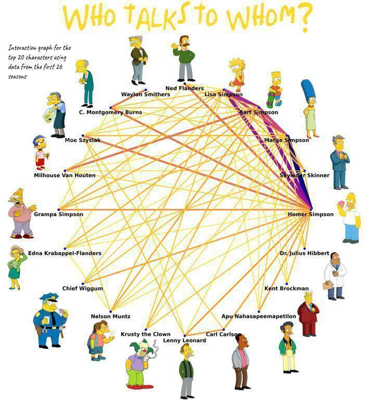


[3] graph_1.jpg  (similarity: -0.9249)


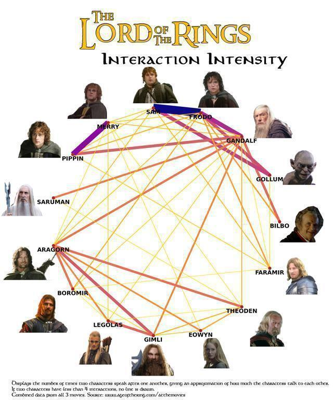


[4] graph_2.jpg  (similarity: -0.9316)


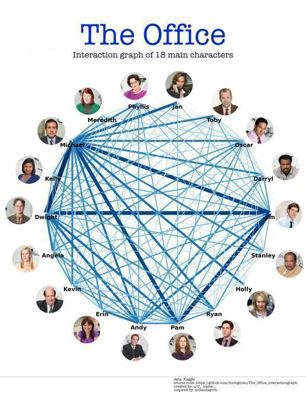

In [2]:
def search(query: str, top_k: int = 5):
    """Embed a text query and return the top_k most similar images from ChromaDB."""
    result = co.embed(
        texts=[query],
        model=MODEL,
        input_type='search_query',
        embedding_types=['float']
    )
    query_embedding = result.embeddings.float_[0]

    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=top_k,
        include=['metadatas', 'distances']
    )

    matches = []
    for metadata, distance in zip(results['metadatas'][0], results['distances'][0]):
        matches.append({
            'filename': metadata['filename'],
            'similarity': round(1 - distance, 4),  # cosine distance → similarity
            'filepath': os.path.join(images_folder, metadata['filename'])
        })
    return matches

# --- Try a search query ---
query = "bar chart showing quarterly revenue growth"
top_k = 5

print(f"Searching for: '{query}'\n")
matches = search(query, top_k=top_k)

for i, match in enumerate(matches):
    print(f"[{i+1}] {match['filename']}  (similarity: {match['similarity']})")
    img = Image.open(match['filepath'])
    img.thumbnail((400, 400))
    display(img)
    print()